In [2]:
import yfinance as yf
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

Implied Volatility Indices 

- CBOE  Volatility  Index   
- CBOE  Crude  Oil Volatility Index  
- CBOE  DJIA  Volatility Index  
- CBOE   Gold   Volatility   Index

DAILY

In [3]:
tickers = ["^VIX", "^OVX", "^VXD", "^GVZ"]

data = pd.DataFrame([])
dataset = []
start = []
end = []

for i in range(2):
    if i == 0:
        end.append(dt.datetime.now())
        start.append(end[i] - dt.timedelta(days=365))
    else:
        end.append(start[i-1])
        start.append(end[i] - dt.timedelta(days=365))
    
    df = yf.download(tickers, start[i], end[i], interval="60m")["Close"].pct_change().dropna()
    df.columns = ["CBOEVolatilityIndex", "CBOECrudeOilVolatilityIndex", "CBOEDJIAVolatilityIndex", "CBOEGoldVolatilityIndex"]
    dataset.append(df)
    data = pd.concat([data, df], axis=0)

#data.reset_index(drop=True, inplace=True)

data

C:\Users\miche\AppData\Local\Temp\ipykernel_41008\419584571.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start[i], end[i], interval="60m")["Close"].pct_change().dropna()
[*********************100%***********************]  4 of 4 completed
C:\Users\miche\AppData\Local\Temp\ipykernel_41008\419584571.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df = yf.download(tickers, start[i], end[i], interval="60m")["Close"].pct_change().dropna()
C:\Users\miche\AppData\Local\Temp\ipykernel_41008\419584571.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start[i], end[i], interval="60m")["Close"].pct_change().dropna()
[*********************100%***********************

,CBOEVolatilityIndex,CBOECrudeOilVolatilityIndex,CBOEDJIAVolatilityIndex,CBOEGoldVolatilityIndex
Datetime,,,,
2024-12-16 15:00:00+00:00,0.000000,0.000000,-0.006998,0.000000
2024-12-16 15:30:00+00:00,-0.011472,-0.005537,0.000000,0.007032
2024-12-16 16:00:00+00:00,0.000000,0.000000,0.011980,0.000000
2024-12-16 16:30:00+00:00,0.000645,-0.010207,0.000000,0.006285
2024-12-16 17:00:00+00:00,0.000000,0.000000,-0.000696,0.000000
...,...,...,...,...
2024-12-13 19:00:00+00:00,0.000000,0.000000,-0.003634,0.000000
2024-12-13 19:30:00+00:00,0.002591,-0.008899,0.000000,-0.001407
2024-12-13 20:00:00+00:00,0.000000,0.000000,0.002188,0.000000


In [4]:
daily_volatility_vix = data.rolling(window=24).std()
daily_volatility_vix.dropna(inplace = True)

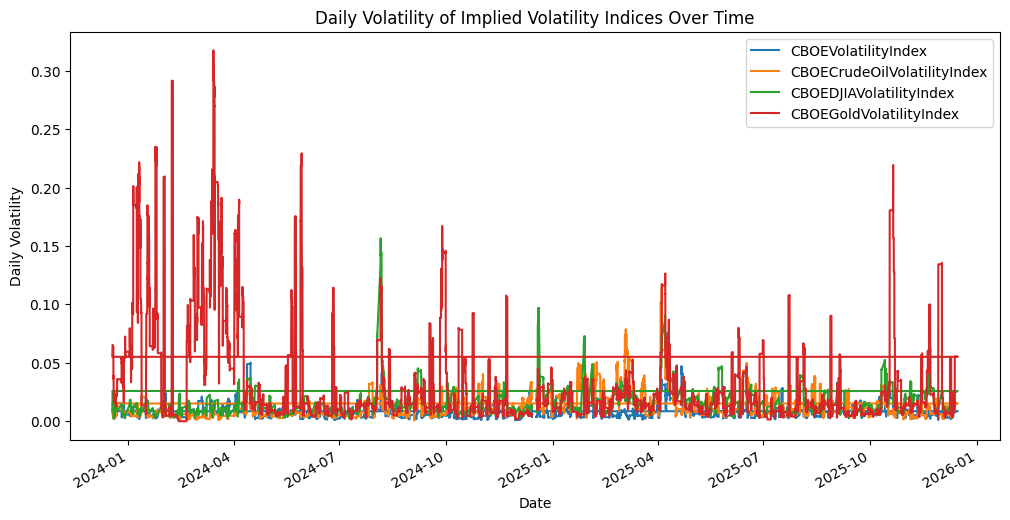

In [5]:
daily_volatility_vix.plot(figsize=(12,6))
plt.title('Daily Volatility of Implied Volatility Indices Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Volatility')
plt.legend()
plt.show()

DAILY

In [3]:
tickers = ["^VIX", "^OVX", "^VXD", "^GVZ"]

end = dt.datetime.now()
start = end - dt.timedelta(days = 365*25)



data_daily_freq = yf.download(tickers, start, end)["Close"].dropna()
#log_returns = np.log(data).diff().dropna()

data_daily_freq.columns = ["CBOEVolatilityIndex", "CBOECrudeOilVolatilityIndex", "CBOEDJIAVolatilityIndex", "CBOEGoldVolatilityIndex"]

C:\Users\miche\AppData\Local\Temp\ipykernel_22792\309433511.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_daily_freq = yf.download(tickers, start, end)["Close"].dropna()
[*********************100%***********************]  4 of 4 completed


In [4]:
data_daily_freq

,CBOEVolatilityIndex,CBOECrudeOilVolatilityIndex,CBOEDJIAVolatilityIndex,CBOEGoldVolatilityIndex
Date,,,,
2008-06-03,22.889999,41.750000,20.240000,18.98
2008-06-04,22.690001,40.770000,20.799999,19.49
2008-06-05,22.780001,41.369999,18.629999,17.67
2008-06-06,23.600000,52.029999,23.559999,21.73
2008-06-09,24.469999,45.570000,23.120001,21.57
...,...,...,...,...
2025-12-05,19.920000,32.060001,15.410000,14.57
2025-12-08,19.580000,33.029999,16.660000,15.49
2025-12-09,20.350000,30.820000,16.930000,15.94


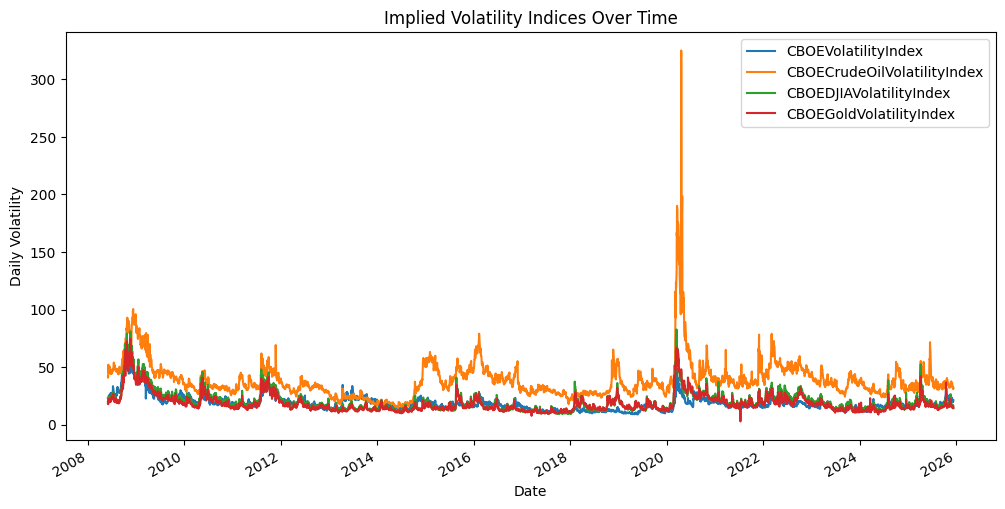

In [ ]:
data_daily_freq.plot(figsize=(12,6))
plt.title('Implied Volatility Indices Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Volatility')
plt.legend()
plt.show()


In [17]:
data_daily_freq.to_csv('daily_implied_volatility_indices.csv')

WEEKLY

In [8]:
weekly_volatility_indices = data_daily_freq.resample("W").mean()

In [9]:
weekly_volatility_indices

,CBOEVolatilityIndex,CBOECrudeOilVolatilityIndex,CBOEDJIAVolatilityIndex,CBOEGoldVolatilityIndex
Date,,,,
2008-06-08,22.9900,43.980000,20.807499,19.467500
2008-06-15,25.0400,48.292000,22.994000,21.302000
2008-06-22,24.7820,47.778000,21.754000,20.362000
2008-06-29,26.9100,44.252001,22.714000,21.492000
2008-07-06,27.2375,45.500000,24.575000,23.230000
...,...,...,...,...
2025-11-16,24.2880,32.578000,18.444000,17.428000
2025-11-23,23.3440,34.436001,24.116000,20.177999
2025-11-30,22.4425,36.380000,18.155000,16.392500


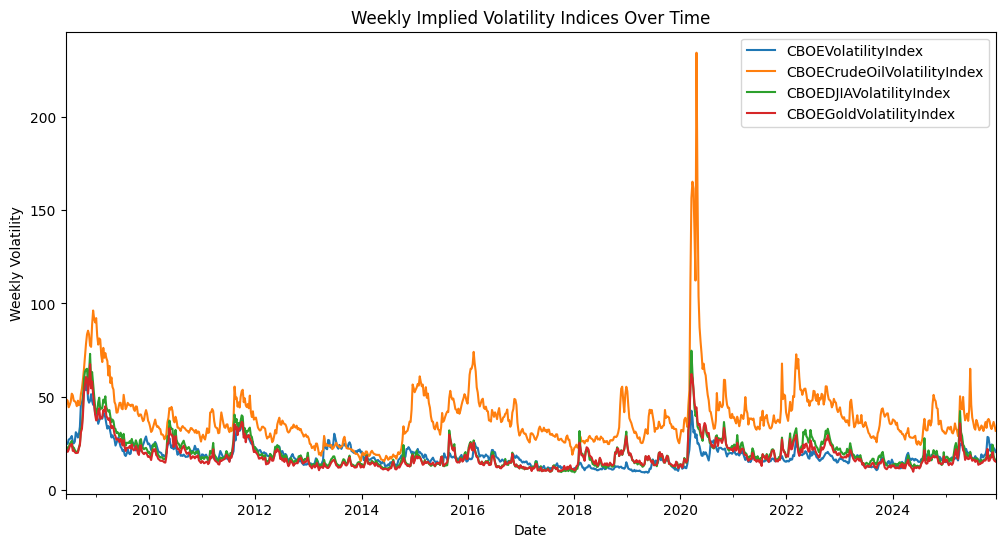

In [10]:
weekly_volatility_indices.plot(figsize = (12,6))
plt.title('Weekly Implied Volatility Indices Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Volatility')
plt.legend()
plt.show()

In [18]:
weekly_volatility_indices.to_csv('weekly_implied_volatility_indices.csv')

MONTHLY

In [11]:
monthly_volatility_vix = data_daily_freq.resample("M").mean()

C:\Users\miche\AppData\Local\Temp\ipykernel_22792\2654766184.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volatility_vix = data_daily_freq.resample("M").mean()


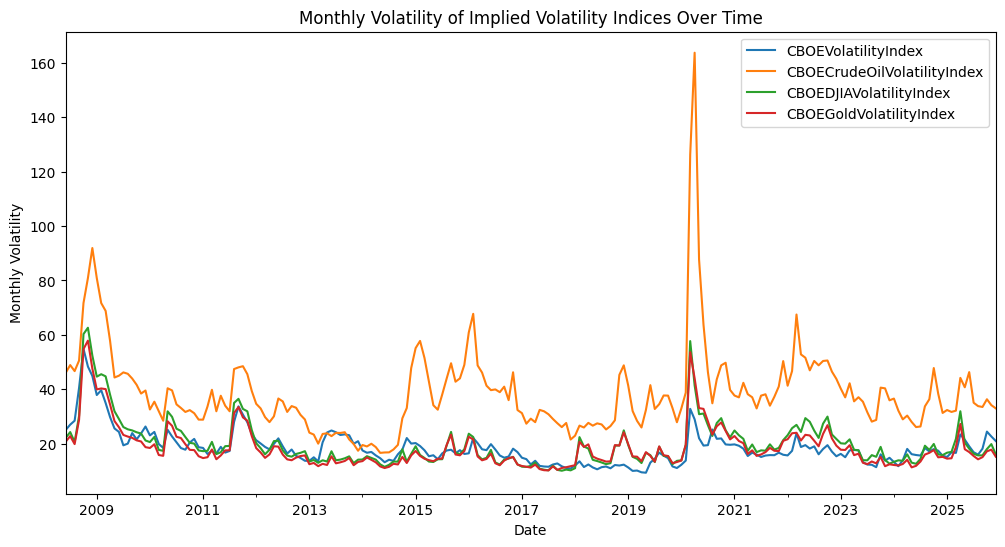

In [12]:
monthly_volatility_vix.plot(figsize=(12,6))
plt.title('Monthly Volatility of Implied Volatility Indices Over Time')
plt.xlabel('Date')
plt.ylabel('Monthly Volatility')
plt.legend()
plt.show()

In [19]:
monthly_volatility_vix.to_csv('monthly_implied_volatility_indices.csv')